# Pitch Classification for Baseball Broadcasting

---
embed-resources: true
---

## Introduction

In this report, we develop a pitch classification model for baseball broadcasting. Using pitch-tracking data, we train a K-Nearest Neighbors (KNN) classifier to predict pitch types based on features such as velocity, spin rate, and movement. The goal is to provide instant pitch identification for live broadcasts, enhancing on-screen analytics and commentary. By evaluating the model's accuracy and efficiency, we assess its suitability for deployment in a fast-paced media environment.

## Methods

In [10]:
# basic imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning imports
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# preprocessing imports
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV


### Data

In [11]:
# load data
import pandas as pd
pitches_train = pd.read_parquet(
    "https://cs307.org/lab/data/pitches-train.parquet",
)
pitches_test = pd.read_parquet(
    "https://cs307.org/lab/data/pitches-test.parquet",
)

Each observation contains information about a single pitch thrown by Shohei Ohtani in either 2022 (train data) or 2023 (test data) during an MLB regular season game.

Here, the train-test split is based on time.

- Train: 2022 MLB Season
- Test: (First Half of) 2023 MLB Season

Original and (mostly) complete documentation for Statcast data can be found in the Statcast Search CSV Documentation. A more detailed reference can be found in Appendix C of Analyzing Baseball Data with R.

#### Response
 `pitch_name`

- `[object]` the name of the pitch, which is the name of the pitch type thrown
#### Features
`release_speed`

- `[float64]` pitch velocity (miles per hour) measured shortly after leaving the pitcher’s hand

`release_spin_rate`

- `[float64]` pitch spin rate (revolutions per minute) measured shortly after leaving the pitcher’s hand

`pfx_x`

- `[float64]` horizontal movement (feet) of the pitch from the catcher’s perspective.

`pfx_z`

- `[float64]` vertical movement (feet) of the pitch from the catcher’s perspective.

stand

- `[object]` side of the plate batter is standing, either L (left) or R (right)

In [35]:
# summary statistics
pitches_train
pitches_train[['pitch_name','release_speed','release_spin_rate']].groupby(by='pitch_name').agg(['mean', 'std'])

release_speed           release_spin_rate            
                         mean       std              mean         std
pitch_name                                                           
4-Seam Fastball     97.270613  1.699270       2217.331933  114.754683
Curveball           77.679730  3.215206       2482.666667  119.854726
Cutter              90.742060  2.364489       2378.424893  206.685887
Sinker              97.160825  1.829592       1972.747368  143.920632
Slider              85.203175  2.401543       2497.619048   78.679306
Split-Finger        89.291346  1.759299       1273.560897  221.291146
Sweeper             85.336419  1.862552       2492.172940  103.176892

This table provides the mean and standard deviation of release speed (mph) for different pitch types. The 4-Seam Fastball (97.27 mph) and Sinker (97.16 mph) are the fastest pitches, followed by the Cutter (90.74 mph). In contrast, Curveballs have the lowest average velocity (77.68 mph), aligning with their role as slower, high-spin breaking pitches. The Sweeper and Slider (both ~85 mph) fall in the mid-range, emphasizing movement over speed. The Split-Finger (89.29 mph) is slightly slower than the Cutter but still relatively fast, compensating with its unique drop. The standard deviations are relatively small, indicating consistent velocity across each pitch type. The Slider and Sweeper exhibit the highest average spin rates (~2497 RPM), making them effective breaking pitches, while the Split-Finger stands out with the lowest spin rate (~1273 RPM), reinforcing its unique tumbling action.

In [ ]:
pitch_counts = pitches_train['pitch_name'].value_counts()  # Get counts
pitch_proportions = pitches_train['pitch_name'].value_counts(normalize=True)  # Get proportions

# Combine both into a DataFrame
pd.DataFrame({'count': pitch_counts, 'proportion': pitch_proportions})  

,count,proportion
pitch_name,,
Sweeper,983,0.374049
4-Seam Fastball,718,0.273212
Split-Finger,312,0.118721
Cutter,233,0.088661
Curveball,222,0.084475
Sinker,97,0.036910
Slider,63,0.023973


In terms of usage, the Sweeper is the most frequently thrown pitch (37.4%), followed by the 4-Seam Fastball (27.3%), suggesting a strategic preference for these pitches. The Slider is the least common (2.4%), despite its high spin rate. This data helps illustrate how different pitches vary in both spin and usage, with certain types favored more in gameplay.

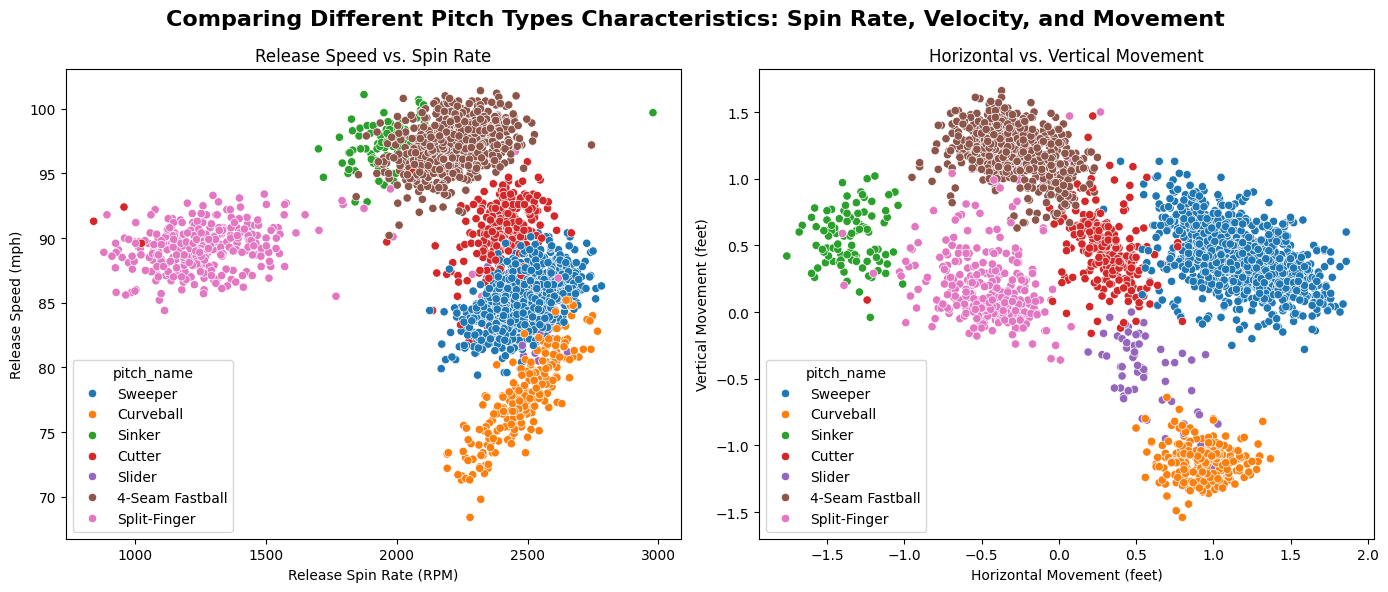

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle("Comparing Different Pitch Types Characteristics: Spin Rate, Velocity, and Movement", fontsize=16, fontweight='bold')

# First plot: Release Speed vs. Spin Rate
sns.scatterplot(
    data=pitches_train, 
    x="release_spin_rate", 
    y="release_speed", 
    hue="pitch_name", 
    palette="tab10", 
    ax=axes[0]
)
axes[0].set_title("Release Speed vs. Spin Rate")
axes[0].set_xlabel("Release Spin Rate (RPM)")
axes[0].set_ylabel("Release Speed (mph)")

# Second plot: Horizontal vs. Vertical Movement
sns.scatterplot(
    data=pitches_train, 
    x="pfx_x",
    y="pfx_z",
    hue="pitch_name", 
    palette="tab10", 
    ax=axes[1]
)
axes[1].set_title("Horizontal vs. Vertical Movement")
axes[1].set_xlabel("Horizontal Movement (feet)")
axes[1].set_ylabel("Vertical Movement (feet)")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

The scatter plot on left highlights the relationship between release speed (mph) and spin rate (RPM) across different pitch types, revealing distinct clusters. 4-Seam Fastballs and Sinkers have the highest velocities (~90-100 mph), with Sinkers exhibiting a lower spin rate. Curveballs and Sliders have high spin rates (~2400-2700 RPM) but lower velocities (~70-90 mph), optimizing movement. The Sweeper and Cutter balance spin and speed, forming intermediate clusters. Notably, the Split-Finger stands out distinctly from all other pitches due to its exceptionally low spin rate (~1000-1500 RPM), making it the easiest to identify on the chart. This lack of spin contributes to its unpredictable, tumbling movement rather than relying on rotational force like other breaking pitches.

The graph on right illustrates the horizontal vs. vertical movement of different pitch types, highlighting more distinct clustering patterns. 4-Seam Fastballs exhibit strong vertical movement with minimal horizontal break, while Sinkers have more horizontal break and slight lift. Curveballs show the most downward movement, aligning with their high spin rate. Sweepers and Sliders have significant horizontal break, with the Sweeper moving more than the Slider. Cutters fall between Fastballs and Sliders, showing moderate movement in both directions. The Split-Finger stands out as the most distinct pitch, with minimal spin and unpredictable movement, reinforcing its unique tumbling action. When combined with the previous graph (Spin Rate vs. Velocity), this visualization confirms that higher spin generally leads to more movement, while low-spin pitches like the Split-Finger rely on natural drop rather than spin-induced break.

Also, when we combine the two graphs, we can see that the Sinker and 4-Seam Fastball are more distinguishable in the graph on the right, indicating that these two features are useful for identifying pitch types. Additionally, the Slider, which was less noticeable before, is now clearly visible in the graph on the right.

### Models

In [17]:
# process data for ML

# create X and y for train
X_train = pitches_train.drop("pitch_name", axis=1)
y_train = pitches_train["pitch_name"]

# create X and y for test
X_test = pitches_test.drop("pitch_name", axis=1)
y_test = pitches_test["pitch_name"]

pitches_train.isna().sum()

pitch_name           0
release_speed        0
release_spin_rate    6
pfx_x                0
pfx_z                0
stand                0
dtype: int64

There is some missing data, so we need to develop a preprocessor for us when train model.

In [46]:
numeric_features = ['release_speed','release_spin_rate','pfx_x','pfx_z']
categorical_features = ['stand']
features = numeric_features + categorical_features
target = "target"

In [ ]:
# train models
knn = KNeighborsClassifier()
# define preprocessing for numeric features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

# define preprocessing for categorical features
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="infrequent_if_exist"),
)

# create general preprocessor
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    remainder="drop",
)
# define the parameter grid
param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 5, 10, 15, 20, 25, 50],
    "kneighborsclassifier__p": [1, 2],
}

# create the pipeline
pipeline = make_pipeline(
    preprocessor,
    knn,
)

# create the grid search
mod = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
)

# fit the grid search
mod.fit(X_train, y_train)

# print the best parameters and the corresponding score
print(f"Best Parameters: {mod.best_params_}")
print(f"Best Cross-Validated Accuracy: {mod.best_score_}")

Best Parameters: {'kneighborsclassifier__n_neighbors': 20, 'kneighborsclassifier__p': 1}
Best Cross-Validated Accuracy: 0.9771645844649648


We develop a classification model using the K-Nearest Neighbors (KNN) algorithm as the primary model. Data preprocessing was implemented using a pipeline to ensure consistency and efficiency. Numerical features were processed using median imputation to handle missing values and standardization to normalize feature scales. Categorical features underwent most frequent imputation and were one-hot encoded to convert them into a suitable format for the model. These preprocessing steps were applied using make_column_transformer() to handle both types of data effectively.

For model optimization, I conducted a grid search with 5-fold cross-validation using GridSearchCV. The hyperparameters tuned included the number of neighbors (n_neighbors), tested at values of 1, 5, 10, 15, 20, 25, and 50, and the distance metric (p), evaluated at 1 (Manhattan distance) and 2 (Euclidean distance). The best hyperparameters were selected based on accuracy, and the final model was trained using these optimized values.

The model’s final train accuracy was 97.716%, demonstrating strong predictive performance. 

## Results

In [26]:
# report model metrics
final_model = make_pipeline(
    preprocessor,
    KNeighborsClassifier(n_neighbors=20),
)
final_model.fit(X_train, y_train)

# predict on the test data
y_test_pred = final_model.predict(X_test)

# calculate and print the test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.9379225568531039


The K-Nearest Neighbors (KNN) model achieved a high test accuracy of 93.79%, indicating that it performs well in classifying different pitch types based on the given features.

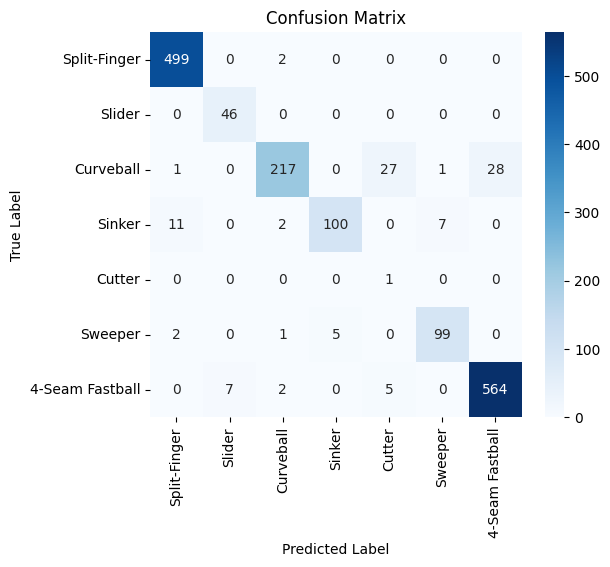

In [44]:
from sklearn.metrics import confusion_matrix
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, final_model.predict(X_test))
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test), yticklabels=set(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix reveals that the model correctly predicted the majority of pitches, with Split-Finger, Slider, and 4-Seam Fastball showing near-perfect classification. However, some misclassifications occurred, particularly with Curveballs being confused with Sinkers and 4-Seam Fastballs, suggesting some overlap in their features. Similarly, a few Sinkers were misclassified as Split-Fingers or 4-Seam Fastballs, likely due to similarities in velocity and movement. Despite these minor errors, the model effectively differentiates most pitches, making it a reliable classifier. 

In [ ]:
# serialize model
from joblib import dump
dump(final_model, "pitches.joblib")

## Discussion

I would use the K-Nearest Neighbors (KNN) classifier for pitch classification in a broadcasting setting, as it meets the necessary requirements for accuracy and real-time performance. The model achieved a test accuracy of 93.79%, demonstrating strong predictive ability and reliable classification across all pitch types. The model can identify the pitch type within a second, it is fast enough to be used in live broadcasting without causing delays in the presentation of real-time analytics.

One limitation of the model is that it sometimes misclassifies Curveballs, often confusing them with Sinkers or 4-Seam Fastballs. This happens because these pitches have similar spin rates and velocities, making them harder to differentiate. However, this is not a major issue for broadcasting, as occasional misclassifications have no real consequences. 

Given these considerations, I conclude that this model is suitable for real-time pitch classification in broadcasting. Its speed, accuracy, and low-risk nature of misclassifications make it a practical and effective tool for enhancing live baseball coverage.